# Import libraries

In [1]:
import tensorflow as tf
from tensorflow.keras.layers import Conv2D , MaxPooling2D , Dropout , Flatten , Dense ,BatchNormalization,Input,ReLU
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint , EarlyStopping
from tensorflow.keras import models , optimizers , regularizers
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image

## Load the training and test datsets

In [2]:
# Load train csv

df_train = pd.read_csv('/kaggle/input/ai-vs-human-generated-dataset/train.csv')

In [3]:
#Load test csv
df_test = pd.read_csv('/kaggle/input/ai-vs-human-generated-dataset/test.csv')

# Clean data

In [4]:
# delete Unnamed column
df_train.drop(columns=['Unnamed: 0'],inplace=True)

In [ ]:
#check if thera are duplicated rows
df_train.duplicated().sum()

In [ ]:
#label 1 -> AI Image
#label 0 -> Human Image
df_train['label'][0]

## Separete data

In [5]:
# Change the format in the rows and put them in a new column called "Images"

df_train['Images'] = df_train['file_name'].apply(lambda x:x.split('/')[1])


In [6]:
#Delete file_name column
df_train.drop(columns = ['file_name'],inplace = True)

## Get data and data Argumentation

In [7]:
# Data Argumentation
# To create more images with similar characteristics

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split = 0.3
    )

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

In [ ]:
#Reset train data generator
#train_generator.reset()

In [8]:
# Change the type of data in the column "label"
df_train['label'] = df_train['label'].astype('string')

In [9]:
# Define the base directory where images are stored
train_dir = "/kaggle/input/ai-vs-human-generated-dataset/train_data"

In [10]:
# Get data of a DataFrame
train_generator = train_datagen.flow_from_dataframe(
    dataframe = df_train,
    directory = train_dir,
    x_col = "Images",
    y_col = "label",
    target_size = (150,150),
    batch_size = 64,
    class_mode = "binary",
    color_mode='rgb',
    subset = "training",
    shuffle=True  
)

validation_generator = train_datagen.flow_from_dataframe(
    dataframe = df_train,
    directory = train_dir,
    x_col = "Images",
    y_col = "label",
    target_size = (150,150),
    batch_size = 64,
    class_mode = "binary",
    color_mode='rgb',
    subset = "validation",
    shuffle=True  
)

Found 55965 validated image filenames belonging to 2 classes.
Found 23985 validated image filenames belonging to 2 classes.


In [11]:
# Shape of each batch
train_generator[0][0].shape

(64, 150, 150, 3)

# Divide validation_generator data 

- 15 % -> validation
- 15 % -> test

In [12]:
# Extract de batches in x_val y y_val from validation_generator
x_val = []
y_val = []
num_batches = len(validation_generator)
for i in range(num_batches):
    batch = validation_generator[i]
    images, labels = batch
    x_val.append(images)
    y_val.append(labels)

x_val = np.concatenate(x_val, axis=0)
y_val = np.concatenate(y_val, axis=0)




In [13]:
print(f"X_train shape: {len(x_val)}")
print(f"y_train shape: {len(y_val)}")

X_train shape: 23985
y_train shape: 23985


In [14]:
# Take 50 % of x_val and  y_val to x_test and y_test

x_test = x_val[:11992]
y_test = y_val[:11992]

x_val = x_val[11992:]
y_val = y_val[11992:]

In [15]:
print(f"x_test shape: {len(x_test)}")
print(f"y_test shape: {len(y_test)}")
print(f"x_val shape: {len(x_val)}")
print(f"y_val shape: {len(y_val)}")

x_test shape: 11992
y_test shape: 11992
x_val shape: 11993
y_val shape: 11993


##  Create Model

In [16]:
def model1 ():

    model = models.Sequential([
    Input(shape=(150, 150, 3)),
    Conv2D(32,(2,2),padding='same',kernel_regularizer=regularizers.l2(0.001)),
    BatchNormalization(),
    ReLU(),
    MaxPooling2D((2,2)),

   
    Conv2D(64,(2,2),padding='same',kernel_regularizer=regularizers.l2(0.001)),
    BatchNormalization(),
    ReLU(),
    MaxPooling2D((2,2)),
    Dropout(0.3),

    
    Conv2D(128,(2,2),padding='same',kernel_regularizer=regularizers.l2(0.001)),
    BatchNormalization(),
    ReLU(),
    MaxPooling2D((2,2)),
    Dropout(0.4),

   
    Conv2D(256,(2,2),padding='same',kernel_regularizer=regularizers.l2(0.001)),
    BatchNormalization(),
    ReLU(),
    MaxPooling2D((2,2)),
   

    Conv2D(512,(2,2),padding='same',kernel_regularizer=regularizers.l2(0.001)),
    BatchNormalization(),
    ReLU(),
    MaxPooling2D((2,2)),
    Dropout(0.5),

    Conv2D(1024,(2,2),padding='same',kernel_regularizer=regularizers.l2(0.001)),
    BatchNormalization(),
    ReLU(),
    MaxPooling2D((2,2)),
    Dropout(0.5),


        


    Flatten(),


    Dense(512,activation='relu',kernel_regularizer=regularizers.l2(0.001)),
    Dropout(0.6),
    Dense(256,activation='relu',kernel_regularizer=regularizers.l2(0.001)),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
    
    ])

    return model

## Callback definition

In [17]:
checkpoint = ModelCheckpoint('best_wights.keras',monitor='val_accuracy', verbose= 1, save_best_only=True)

## Compilation

In [18]:
model_1 = model1()

In [19]:
model_1.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

# Training

In [21]:
hist = model_1.fit(train_generator,
                  
                  epochs=30,
                  validation_data=(x_val,y_val),
                  
                  callbacks=[checkpoint])

Epoch 1/30
874/875 ━━━━━━━━━━━━━━━━━━━━ 0s 782ms/step - accuracy: 0.8708 - loss: 2.0210
Epoch 1: val_accuracy improved from -inf to 0.55324, saving model to best_wights.keras
875/875 ━━━━━━━━━━━━━━━━━━━━ 704s 798ms/step - accuracy: 0.8709 - loss: 2.0195 - val_accuracy: 0.5532 - val_loss: 1.1503
Epoch 2/30
874/875 ━━━━━━━━━━━━━━━━━━━━ 0s 511ms/step - accuracy: 0.9047 - loss: 0.4987
Epoch 2: val_accuracy improved from 0.55324 to 0.90795, saving model to best_wights.keras
875/875 ━━━━━━━━━━━━━━━━━━━━ 454s 514ms/step - accuracy: 0.9047 - loss: 0.4986 - val_accuracy: 0.9079 - val_loss: 0.4576
Epoch 3/30
874/875 ━━━━━━━━━━━━━━━━━━━━ 0s 505ms/step - accuracy: 0.9069 - loss: 0.3690
Epoch 3: val_accuracy did not improve from 0.90795
875/875 ━━━━━━━━━━━━━━━━━━━━ 449s 508ms/step - accuracy: 0.9069 - loss: 0.3690 - val_accuracy: 0.8600 - val_loss: 0.4589
Epoch 4/30
874/875 ━━━━━━━━━━━━━━━━━━━━ 0s 516ms/step - accuracy: 0.9073 - loss: 0.3545
Epoch 4: val_accuracy did not improve from 0.90795
875/87

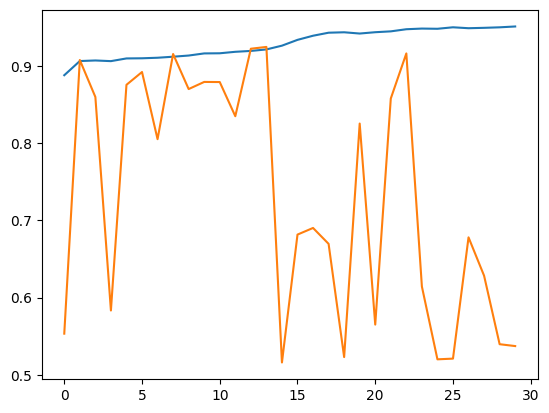

In [22]:
plt.plot(hist.history['accuracy'])
plt.plot(hist.history['val_accuracy'])
plt.show()

### Take the best weights to ather model

In [23]:
#Copy architecture of the model
model_best = model_1

#Charge the best weigths to model_best
model_best.load_weights('best_wights.keras')

#Compile the model
model_best.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

#Evaluate
model_best.evaluate(x_test,y_test)

375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9179 - loss: 0.3865


[0.3855952024459839, 0.918779194355011]

# Prediction

In [24]:
y_pred = model_best.predict(x_test)

375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step


In [25]:
y_pred = y_pred.flatten()

In [26]:
y_pred = np.where(y_pred>0.5,1,0)

# Get F1 Score

In [27]:
from sklearn.metrics import f1_score

In [28]:
#  F1-score
f1 = f1_score(y_test, y_pred,average='binary')

print(f"F1-score: {f1:.2f}")

F1-score: 0.92


# Load test images

In [30]:
import cv2
import os
import numpy as np

# Path to the folder with test images
test_dir ="/kaggle/input/ai-vs-human-generated-dataset/test_data_v2"

# Get the images
imagenes = []
for archivo in os.listdir(test_dir):
    if archivo.endswith('.jpg') or archivo.endswith('.png'):  
        img = cv2.imread(os.path.join(test_dir, archivo))  
        img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (150, 150))  
        
        img = img / 255.0  
        imagenes.append(img)

imagenes = np.array(imagenes)  
print("Forma del array de imágenes:", imagenes.shape)


Forma del array de imágenes: (5540, 150, 150, 3)


In [ ]:
#Change iamges to gray scale
imagenes_gray=np.mean(imagenes, axis=-1,keepdims=True)

# Prediction in the test data

In [31]:
y_predict_test = model_best.predict(imagenes)


174/174 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step


In [32]:
#Change de value to 1 or 0
y_predict_test = np.where(y_predict_test>0.5,1,0)

#Create Dataframe with predictions and images id's
df_final = pd.DataFrame()
df_final['id'] = df_test['id'].values
df_final['label'] = y_predict_test


In [33]:
df_final

,id,label
0,test_data_v2/1a2d9fd3e21b4266aea1f66b30aed157.jpg,0
1,test_data_v2/ab5df8f441fe4fbf9dc9c6baae699dc7.jpg,1
2,test_data_v2/eb364dd2dfe34feda0e52466b7ce7956.jpg,0
3,test_data_v2/f76c2580e9644d85a741a42c6f6b39c0.jpg,0
4,test_data_v2/a16495c578b7494683805484ca27cf9f.jpg,0
...,...,...
5535,test_data_v2/483412064ff74d9d9472d606b65976d9.jpg,0
5536,test_data_v2/c0b49ba4081a4197b422dac7c15aea7f.jpg,1
5537,test_data_v2/01454aaedec140c0a3ca1f48028c41cf.jpg,1
5538,test_data_v2/e9adfea8b67e4791968c4c2bdd8ec343.jpg,0


In [34]:
#Load file sumbission.csv
output = pd.DataFrame({'id': df_final.id, 'label': df_final.label})
output.to_csv('submission.csv', index=False)
print("Your submission was successfully saved!")

Your submission was successfully saved!


In [35]:
value_counts = output['label'].value_counts()
value_counts

label
0    2997
1    2543
Name: count, dtype: int64

In [ ]:
def Constructor_model (hp):

    model = models.Sequential()
    
    hp_learning_rate = hp.Choice('learning_rate', values = [1e-2, 1e-3, 1e-4])
    hp_units = hp.Int("units", min_value = 64, max_value = 512, step = 64)
    
    model.add(Conv2D(32,(2,2),padding='same',kernel_regularizer=regularizers.l2(0.01)))
    model.add(BatchNormalization())
    model.add(ReLU())
    model.add(MaxPooling2D((2,2)))

   
    model.add(Conv2D(64,(2,2),padding='same',kernel_regularizer=regularizers.l2(0.01)))
    model.add(BatchNormalization())
    model.add(ReLU())
    model.add(MaxPooling2D((2,2)))
    model.add(Dropout(0.3))

    
    model.add(Conv2D(hp_units,(2,2),padding='same',kernel_regularizer=regularizers.l2(hp_learning_rate)))
    model.add(BatchNormalization())
    model.add(ReLU())
    model.add(MaxPooling2D((2,2)))
    model.add(Dropout(0.4))


   
    model.add(Conv2D(hp_units,(2,2),padding='same',kernel_regularizer=regularizers.l2(hp_learning_rate)))
    model.add(BatchNormalization())
    model.add(ReLU())
    model.add(MaxPooling2D((2,2)))
    model.add(Dropout(0.5))



        


    model.add(Flatten()),


    model.add(Dense(hp_units,activation='relu',kernel_regularizer=regularizers.l2(hp_learning_rate)))
    model.add(Dropout(0.6))
    model.add(Dense(1, activation='sigmoid'))
    
    model.compile(optimizer = keras.optimizers.Adam(learning_rate=hp_learning_rate),loss = "binary_crossentropy", metrics = ["accuracy"])

    return model

In [ ]:
tuner = kt.Hyperband(
    Constructor_model,
    objective = "val_accuracy",
    max_epochs = 10,
    factor = 3,
    directory = "models/",
    project_name = "Images_AI_Humans"
)

In [ ]:
tuner.search(train_generator, epochs =10, validation_data = (x_val,y_val))

best_hps = tuner.get_best_hyperparameters(num_trials =1)[0]

In [ ]:
best_hps

In [ ]:
hypermodel = tuner.hypermodel.build(best_hps)

history_hypermodel = hypermodel.fit(
    train_generator,
    epochs = 20,
    validation_data = (x_val,y_val)
)

In [ ]:
hypermodel.evaluate(x_test , y_test)